# 🏦 Credit Card Default Prediction — Exploratory Data Analysis (EDA)

## Dataset
**Source:** [UCI Machine Learning Repository — Default of Credit Card Clients](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)

This dataset contains information on credit card clients in Taiwan from April to September 2005, including demographic details, credit limit, repayment history, bill statements, and payment amounts. The target variable is `default.payment.next.month` (1 = default, 0 = no default).

The dataset contains **30,000 rows** and **25 columns** (including the target variable).

> **⚠️ Important Note on Data Dictionary Corrections**
> The original Kaggle data description contains several inaccuracies regarding the valid values for certain columns. These were clarified by directly contacting the dataset creator (Professor I-Cheng Yeh). The corrected definitions, sourced from this [Kaggle discussion forum](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/discussion/34608), are as follows:
> - **EDUCATION:** 1 = graduate school, 2 = university, 3 = high school, 0/4/5/6 = others
> - **MARRIAGE:** 1 = married, 2 = single, 3 = divorce, 0 = others
> - **PAY_0 – PAY_6:** -2 = no consumption, -1 = paid in full, 0 = use of revolving credit, 1–8 = payment delay for 1–8 months, 9 = payment delay for 9 months and above
>
> These corrections were critical in resolving apparent anomalies in the data and informed several preprocessing decisions in this notebook.

---

## Objectives
1. Understand the dataset structure — data types, missing values, and basic statistics
2. Explore the target variable — distribution of defaults vs non-defaults and class imbalance
3. Investigate feature distributions — univariate analysis of numerical and categorical features
4. Uncover relationships between features and the target variable — bivariate analysis
5. Assess feature correlations — Pearson correlation for numerical features, Cramér's V for categorical features
6. Define preprocessing and feature engineering strategies based on findings

---

## Evaluation Metrics
Given the class imbalance in the target variable (~78% non-default, ~22% default) and the business objective of minimising financial risk, accuracy alone is not a sufficient metric. The following metrics are prioritised:

- **Recall** — the most critical metric, measuring the model's ability to correctly identify defaulters. A missed defaulter (false negative) represents a direct financial loss to the bank.
- **Precision** — also considered, as incorrectly flagging a reliable customer as a defaulter (false positive) results in lost business.
- **F1-Score** — balances precision and recall, providing a single metric for model comparison.
- **ROC-AUC** — measures the model's overall ability to distinguish between defaulters and non-defaulters across different decision thresholds.

In [37]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading dataset
df = pd.read_csv('../data/raw/UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
df.shape

(30000, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

* No null values
* All the features are stored in numerical form but are not actually numerical

In [6]:
# Dropping id column
df = df.drop('ID', axis=1)

In [7]:
df.duplicated().sum()

np.int64(35)

In [8]:
# Dropping duplicates
df = df.drop_duplicates().reset_index(drop=True)

In [9]:
df.shape

(29965, 24)

## Exploratory Data Analysis

### Univariate Analysis (Categorical & Binary Features)

In [10]:
# Dataframe with categorical variables and converting them to type 'categorical'
cat_cols_list = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default.payment.next.month']
cat_cols = df[cat_cols_list].copy()
cat_cols = cat_cols.astype('category')
cat_cols.describe().transpose()

,count,unique,top,freq
SEX,29965,2,2,18091
EDUCATION,29965,7,2,14019
MARRIAGE,29965,4,2,15945
PAY_0,29965,11,0,14737
PAY_2,29965,11,0,15730
PAY_3,29965,11,0,15764
PAY_4,29965,11,0,16455
PAY_5,29965,10,0,16947
PAY_6,29965,10,0,16286
default.payment.next.month,29965,2,0,23335


* Need to check EDUCATION, MARRIAGE, PAY_0, PAY_2, PAY_3 and PAY_4. They have extra unique values.

In [11]:
for i in cat_cols_list:
    print(i)
    print(cat_cols[i].unique())

SEX
[2, 1]
Categories (2, int64): [1, 2]
EDUCATION
[2, 1, 3, 5, 4, 6, 0]
Categories (7, int64): [0, 1, 2, 3, 4, 5, 6]
MARRIAGE
[1, 2, 3, 0]
Categories (4, int64): [0, 1, 2, 3]
PAY_0
[2, -1, 0, -2, 1, ..., 4, 8, 7, 5, 6]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_2
[2, 0, -1, -2, 3, ..., 7, 4, 1, 6, 8]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_3
[-1, 0, 2, -2, 3, ..., 6, 7, 1, 5, 8]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_4
[-1, 0, -2, 2, 3, ..., 5, 7, 6, 1, 8]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_5
[-2, 0, -1, 2, 3, 5, 4, 7, 8, 6]
Categories (10, int64): [-2, -1, 0, 2, ..., 5, 6, 7, 8]
PAY_6
[-2, 2, 0, -1, 3, 6, 4, 7, 8, 5]
Categories (10, int64): [-2, -1, 0, 2, ..., 5, 6, 7, 8]
default.payment.next.month
[1, 0]
Categories (2, int64): [0, 1]


In [12]:
for i in cat_cols_list:
    print(cat_cols[i].value_counts().sort_index())

SEX
1    11874
2    18091
Name: count, dtype: int64
EDUCATION
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64
MARRIAGE
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64
PAY_0
-2     2750
-1     5682
 0    14737
 1     3667
 2     2666
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64
PAY_2
-2     3752
-1     6046
 0    15730
 1       28
 2     3926
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64
PAY_3
-2     4055
-1     5934
 0    15764
 1        4
 2     3819
 3      240
 4       75
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64
PAY_4
-2     4318
-1     5683
 0    16455
 1        2
 2     3159
 3      180
 4       68
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64
PAY_5
-2     4516
-1     5535
 0    16947
 2     2626
 3      178
 4       83
 5       17
 6        

* Upon further investigation, I found a discussion forum that has info from the creator of the dataset. The discussion stated that the range for PAY_0 to PAY_6 is -2 to 9. Therefore, we can conclude that all the values for PAY_0 to PAY_6 are correct.
* Education (1 = graduate school; 2 = university; 3 = high school; 0, 4, 5, 6 = others). These are the true values of the education according to the author. We can merge 0, 4, 5 and 6 as they all represent 'other'.
* Marriage (1 = married; 2 = single; 3 = divorce; 0=others). These are the true values of Marriage according to the creator of the dataset. Therefore, all the values seem correct.

In [13]:
# Merging 0, 4, 5, and 6 in Education
cat_cols['EDUCATION'] = cat_cols['EDUCATION'].replace({4:0, 5:0, 6:0})
cat_cols['EDUCATION'].value_counts().sort_values()

EDUCATION
0      468
3     4915
1    10563
2    14019
Name: count, dtype: int64

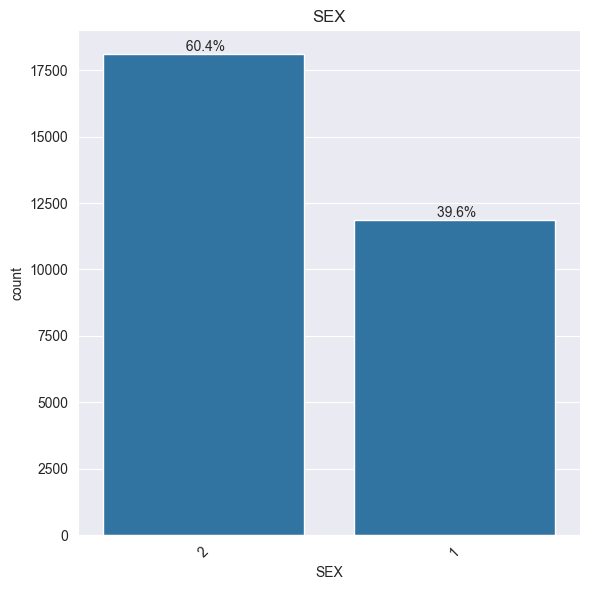

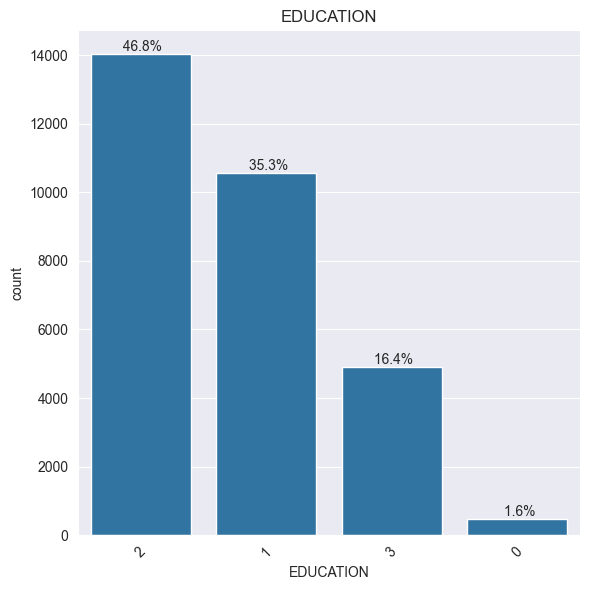

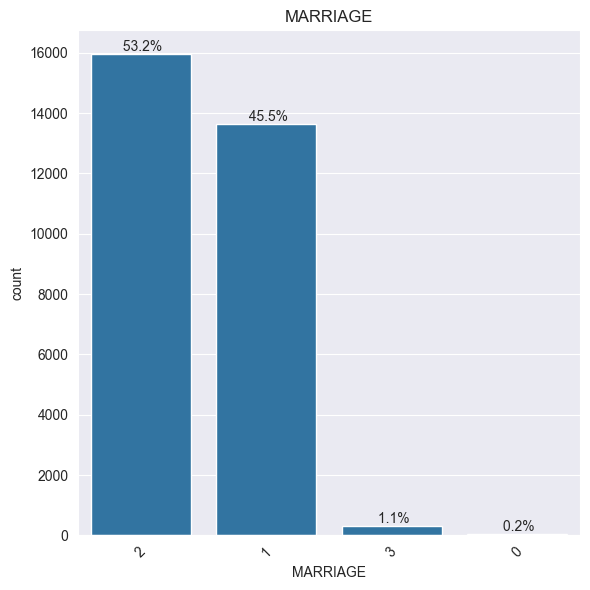

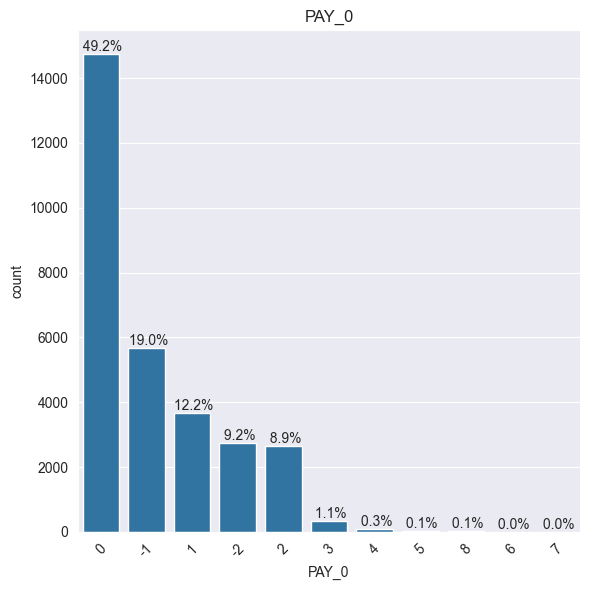

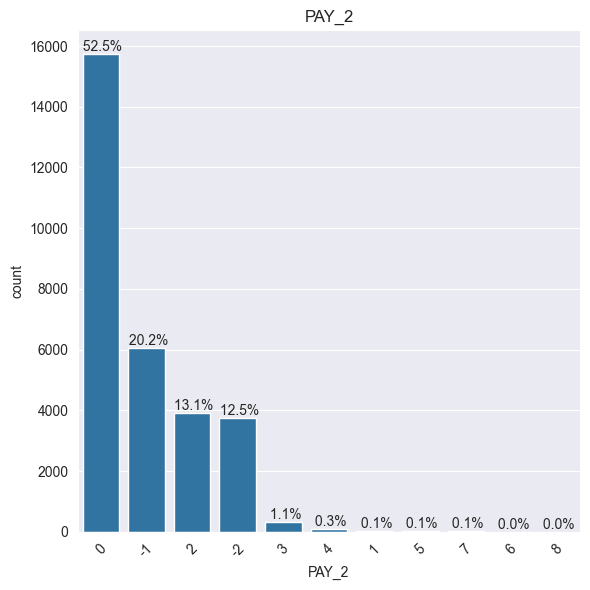

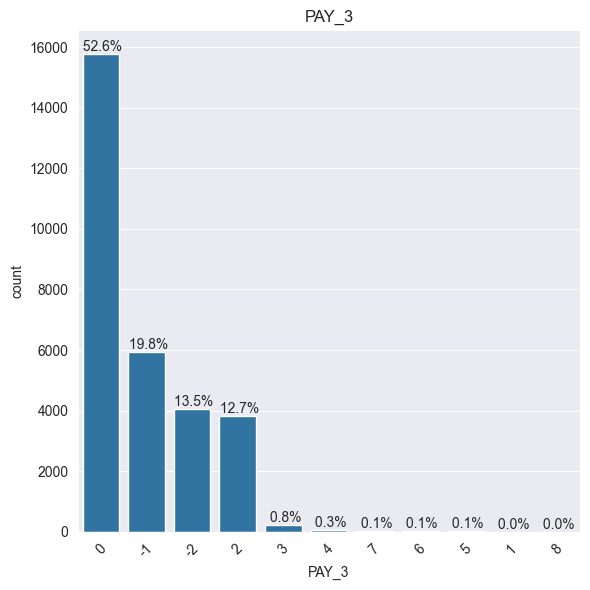

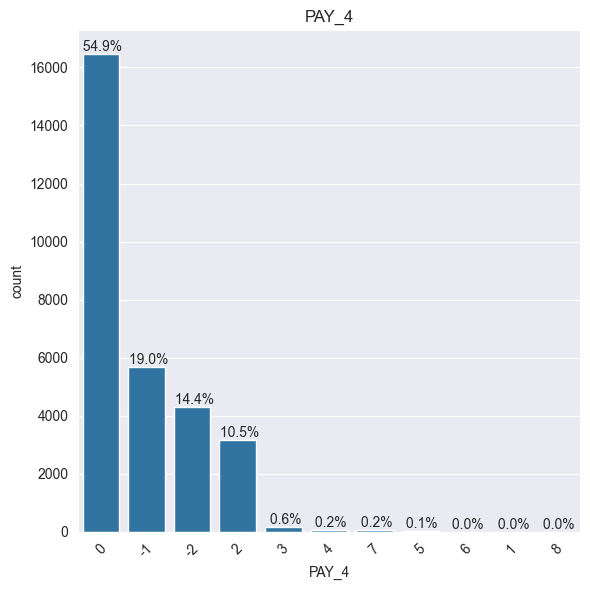

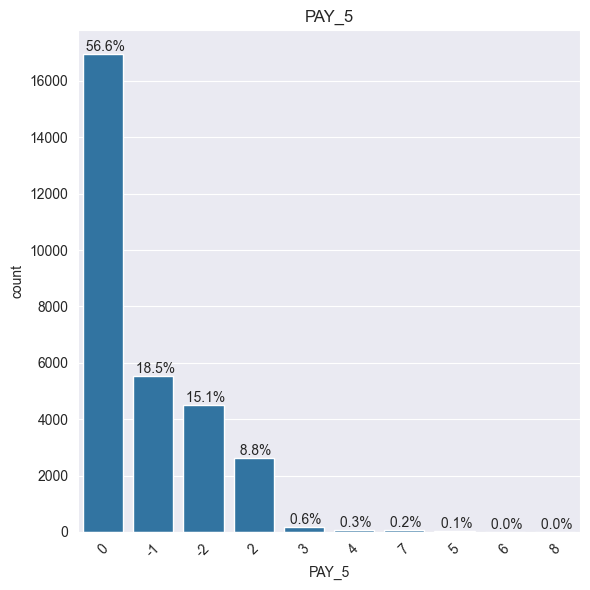

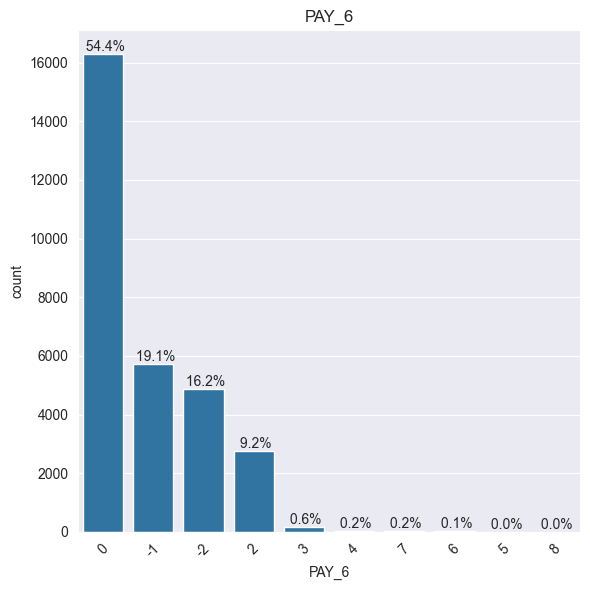

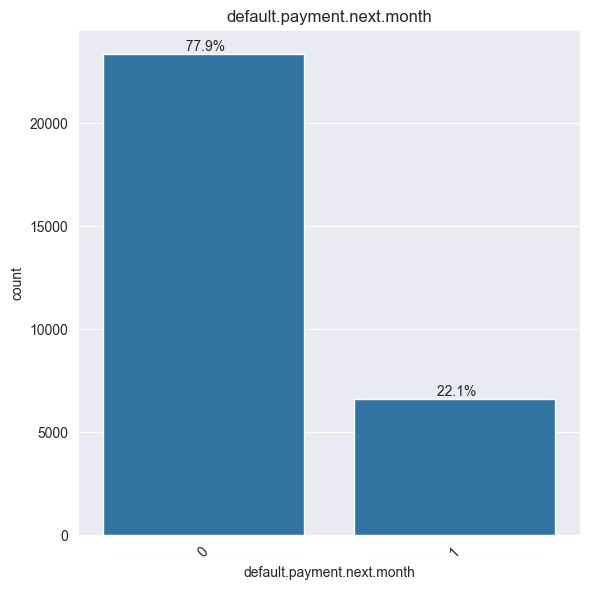

In [14]:
# Plotting countplots for the categorical variables
for i in cat_cols.columns:
    plt.figure(figsize=(6,6))

    ax = sns.countplot(x= cat_cols[i], order= cat_cols[i].value_counts().index)

    total = len(cat_cols[i].dropna())

    for j in ax.patches:
        percentage = 100 * j.get_height()/total
        ax.annotate(
            f'{percentage: .1f}%',
            (j.get_x() + j.get_width() / 2., j.get_height()),
            ha = 'center',
            va = 'bottom'
        )

    plt.title(f'{i}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### SEX
* The dataset has more females (2) at 60.4% than males (1) at 39.6%
* There is a noticeable class imbalance. We may have to be cautious of this if this turns out to be an important feature.

#### EDUCATION
* The dataset is dominated by university graduates (2) at 46.8% and graduate school (1) at 35.3%, meaning over 80% of clients are highly educated
* This suggests the bank's credit clients tend to be well-educated, which makes sense as educated individuals are more likely to qualify for credit

#### MARRIAGE
* The dataset is fairly balanced between single (2) at 53.2% and married (1) at 45.5% — together they make up nearly 99% of the data.
* Divorced (3) is only 1.1% and unknown (0) is just 0.2%

#### PAY_0 – PAY_6 (Repayment History)
* Class **0** appears to be the most frequent category, accounting for a significant proportion of the observations (in many cases close to 50%).
* Classes **-2, -1, and 2** also contain a substantial number of data points, indicating they are relatively well-represented in the dataset.
* The remaining classes (higher delay values) have very few observations, highlighting a potential issue of **class imbalance** within these features.
* One possible approach to address this imbalance is **binning**:
  * Combine classes **1 and 2** into a single group
  * Group all classes **≥ 3** into another category
* However, before applying such transformations, it is important to perform **bivariate analysis** to ensure that meaningful patterns or predictive signals are not lost.

#### default.payment.next.month
* This is the target variable. Class **0** accounts for 77.9% of the data while class **1** accounts for 22.1% of the data.
* This suggests serious imbalance in our target variable.
* Different strategies can be explored to deal with this:
    * Class Weights
    * SMOTE
    * Threshold Tuning

### Univariate Analysis (Numerical Features)

In [15]:
num_cols_list = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
num_cols =  df[num_cols_list].copy()
num_cols.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29965.0,167442.005006,129760.135222,10000.0,50000.0,140000.0,240000.0,1000000.0
AGE,29965.0,35.487969,9.219459,21.0,28.0,34.0,41.0,79.0
BILL_AMT1,29965.0,51283.009778,73658.132403,-165580.0,3595.0,22438.0,67260.0,964511.0
BILL_AMT2,29965.0,49236.366294,71195.567392,-69777.0,3010.0,21295.0,64109.0,983931.0
BILL_AMT3,29965.0,47067.916069,69371.352323,-157264.0,2711.0,20135.0,60201.0,1664089.0
BILL_AMT4,29965.0,43313.329885,64353.514373,-170000.0,2360.0,19081.0,54601.0,891586.0
BILL_AMT5,29965.0,40358.334390,60817.130623,-81334.0,1787.0,18130.0,50247.0,927171.0
BILL_AMT6,29965.0,38917.012281,59574.147742,-339603.0,1262.0,17124.0,49252.0,961664.0
PAY_AMT1,29965.0,5670.099316,16571.849467,0.0,1000.0,2102.0,5008.0,873552.0
PAY_AMT2,29965.0,5927.983180,23053.456645,0.0,850.0,2010.0,5000.0,1684259.0


* All BILL_AMTs have negative values. These are still valid inputs as they can be overpayments, refunds or cashback credit.

In [16]:
# checking for percentage of negative values in BILL_ATMs
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
for i in bill_cols:
    neg_count = (df[i] < 0).sum()
    print(f'{i}: {neg_count} negative values ({100*neg_count/len(df):.1f}%)')

BILL_AMT1: 590 negative values (2.0%)
BILL_AMT2: 669 negative values (2.2%)
BILL_AMT3: 655 negative values (2.2%)
BILL_AMT4: 675 negative values (2.3%)
BILL_AMT5: 655 negative values (2.2%)
BILL_AMT6: 688 negative values (2.3%)


* Very small portion have overpayments, refunds or cashback credt. This seems like a real scenario.

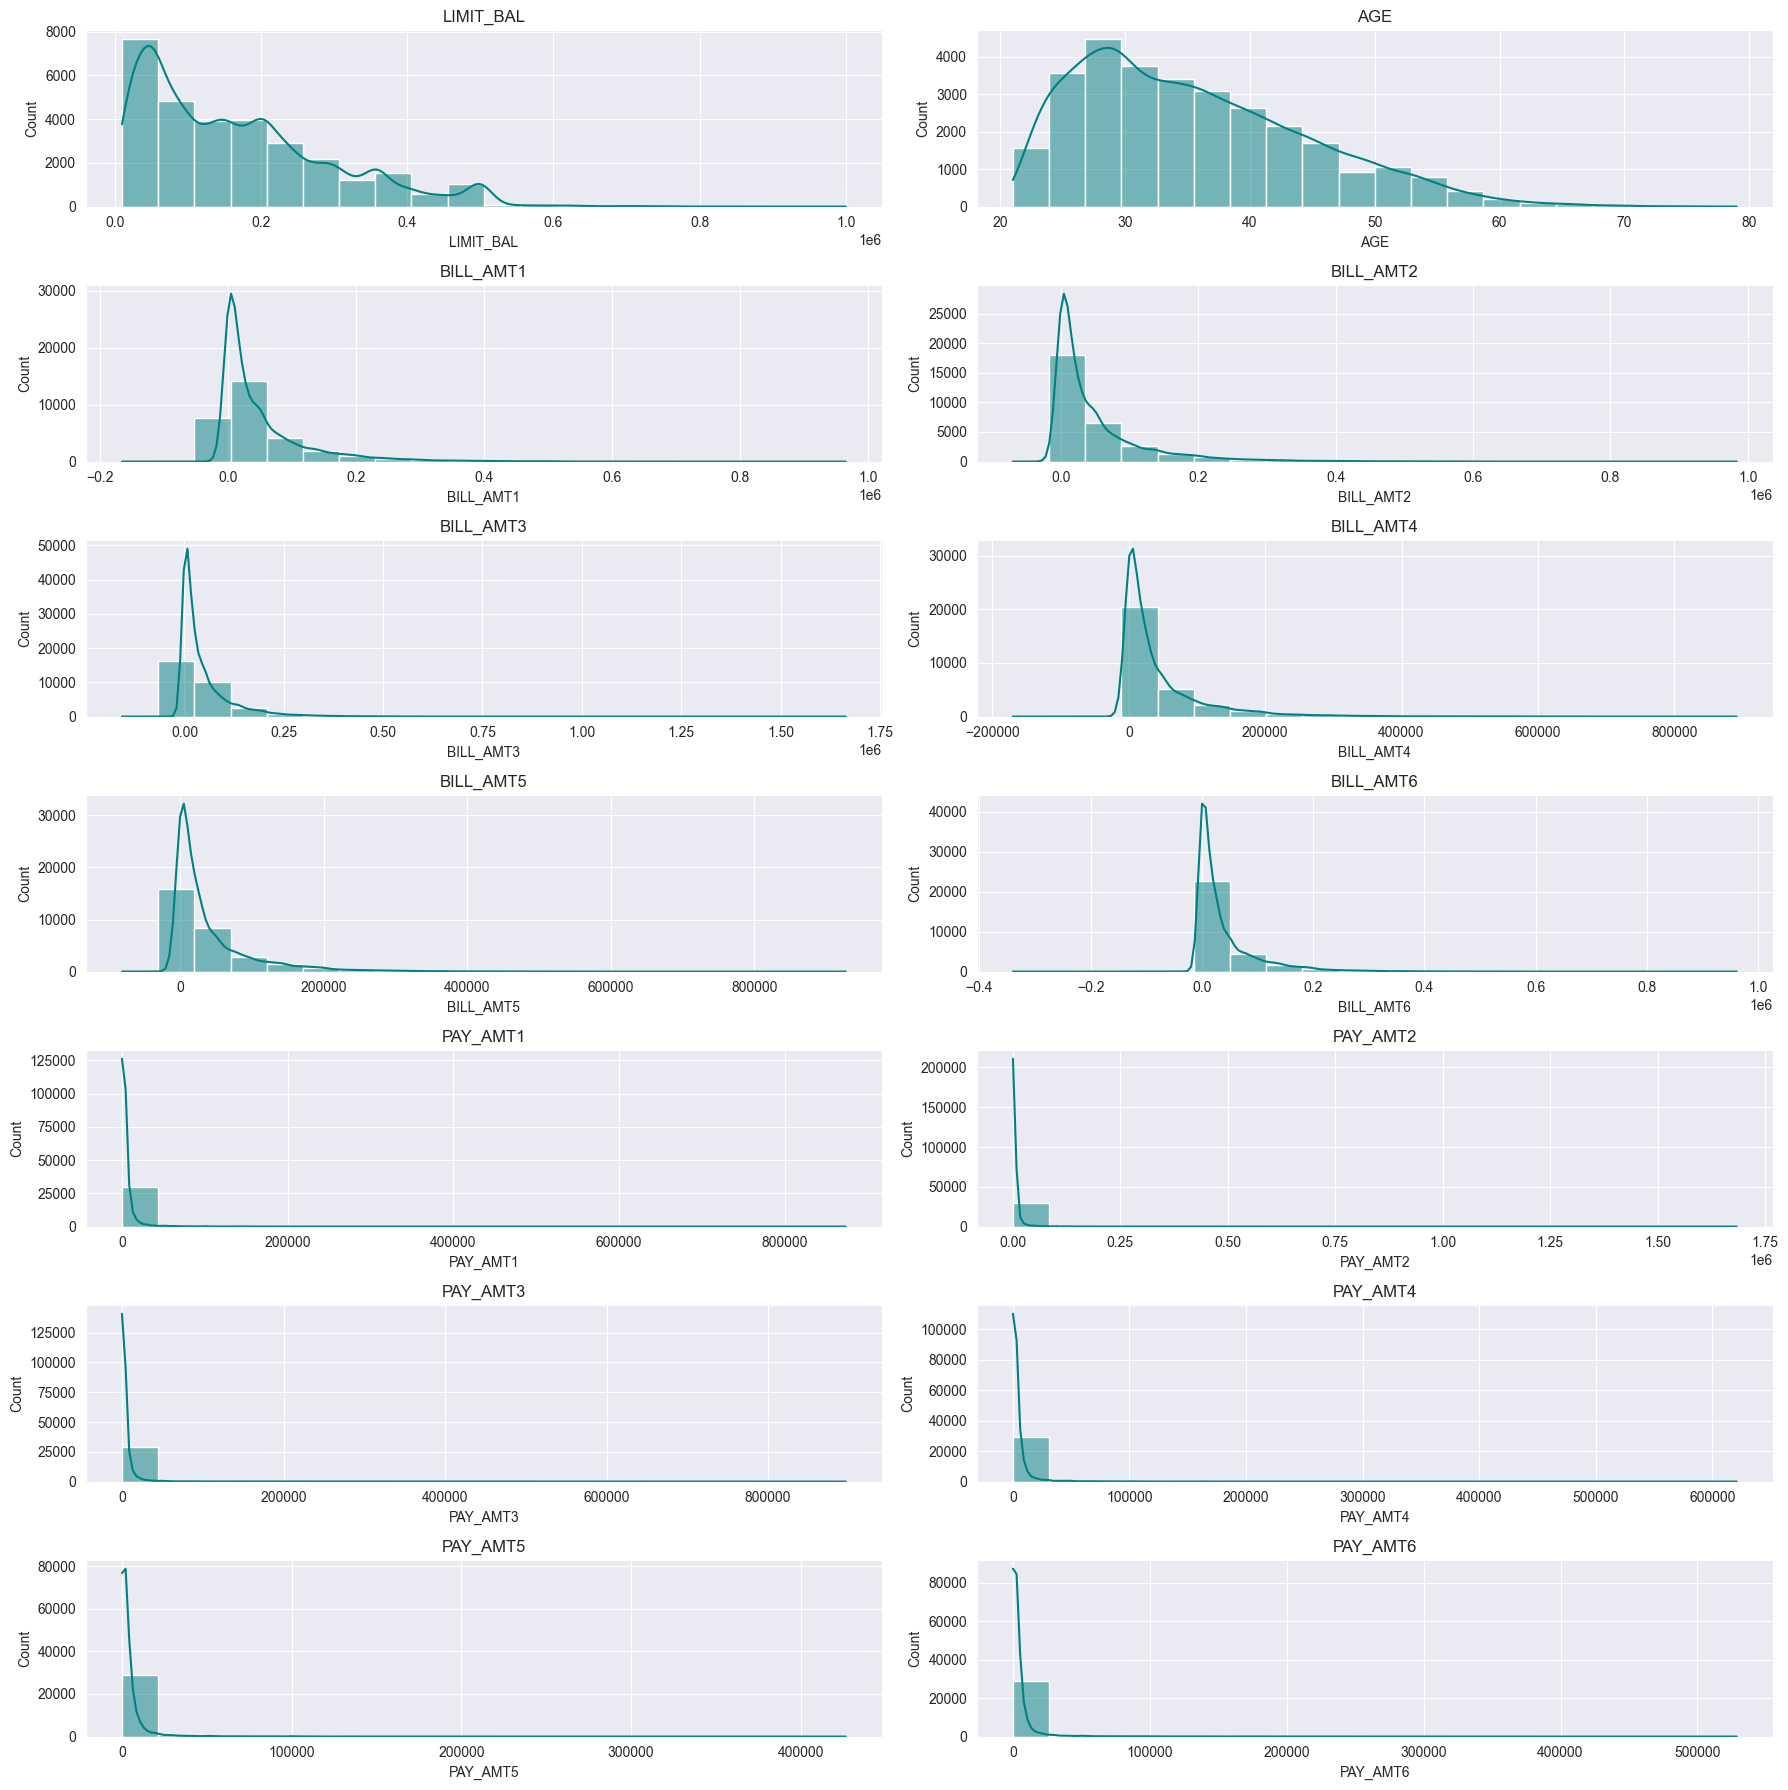

In [17]:
# Histograms for numerical features
plt.figure(figsize=(18,18))
for i, j in enumerate(num_cols_list,  1):
    plt.subplot(7,2,i)
    kde = True
    sns.histplot(num_cols[j], kde=True, color='teal', bins=20)
    plt.title(f'{j}')

plt.tight_layout()
plt.show()

#### LIMIT_BAL (Credit limit)
* Right skewed — most customers have lower credit limits, with a long tail of high-limit customers.
*  The bulk of customers have limits between 0–200,000 NT dollars.
* A small number of very high credit limits exist, suggesting a few wealthy/high-trust customers.

#### Age
* Right skewed but mildly — most customers are in their late 20s to mid 30s.
* Very few customers above 60, which makes sense for a credit card dataset.

#### BILL_AMT1–6
* All are heavily right skewed with a very sharp peak near zero.
* The majority of customers have low or near-zero bill amounts.
* Long tails extending to very high values indicate a small number of customers with very large bills.
* The distributions are very consistent across all 6 months, suggesting stable billing behaviour over time.

#### PAY_AMT1–6
* Extremely right skewed — the most skewed features in the dataset.
* The vast majority of customers make very small payments or zero payments.
* A tiny number of customers make very large payments, creating extremely long tails.
* The spike at zero is particularly notable — this likely represents customers who made no payment at all that month, which could an important signal for default prediction.

#### General Observation
* Skewness is a concern for all the numerical features. This needs to be handled with some kind of transformation.
* It also looks like there are a lot of outliers in all of the features.

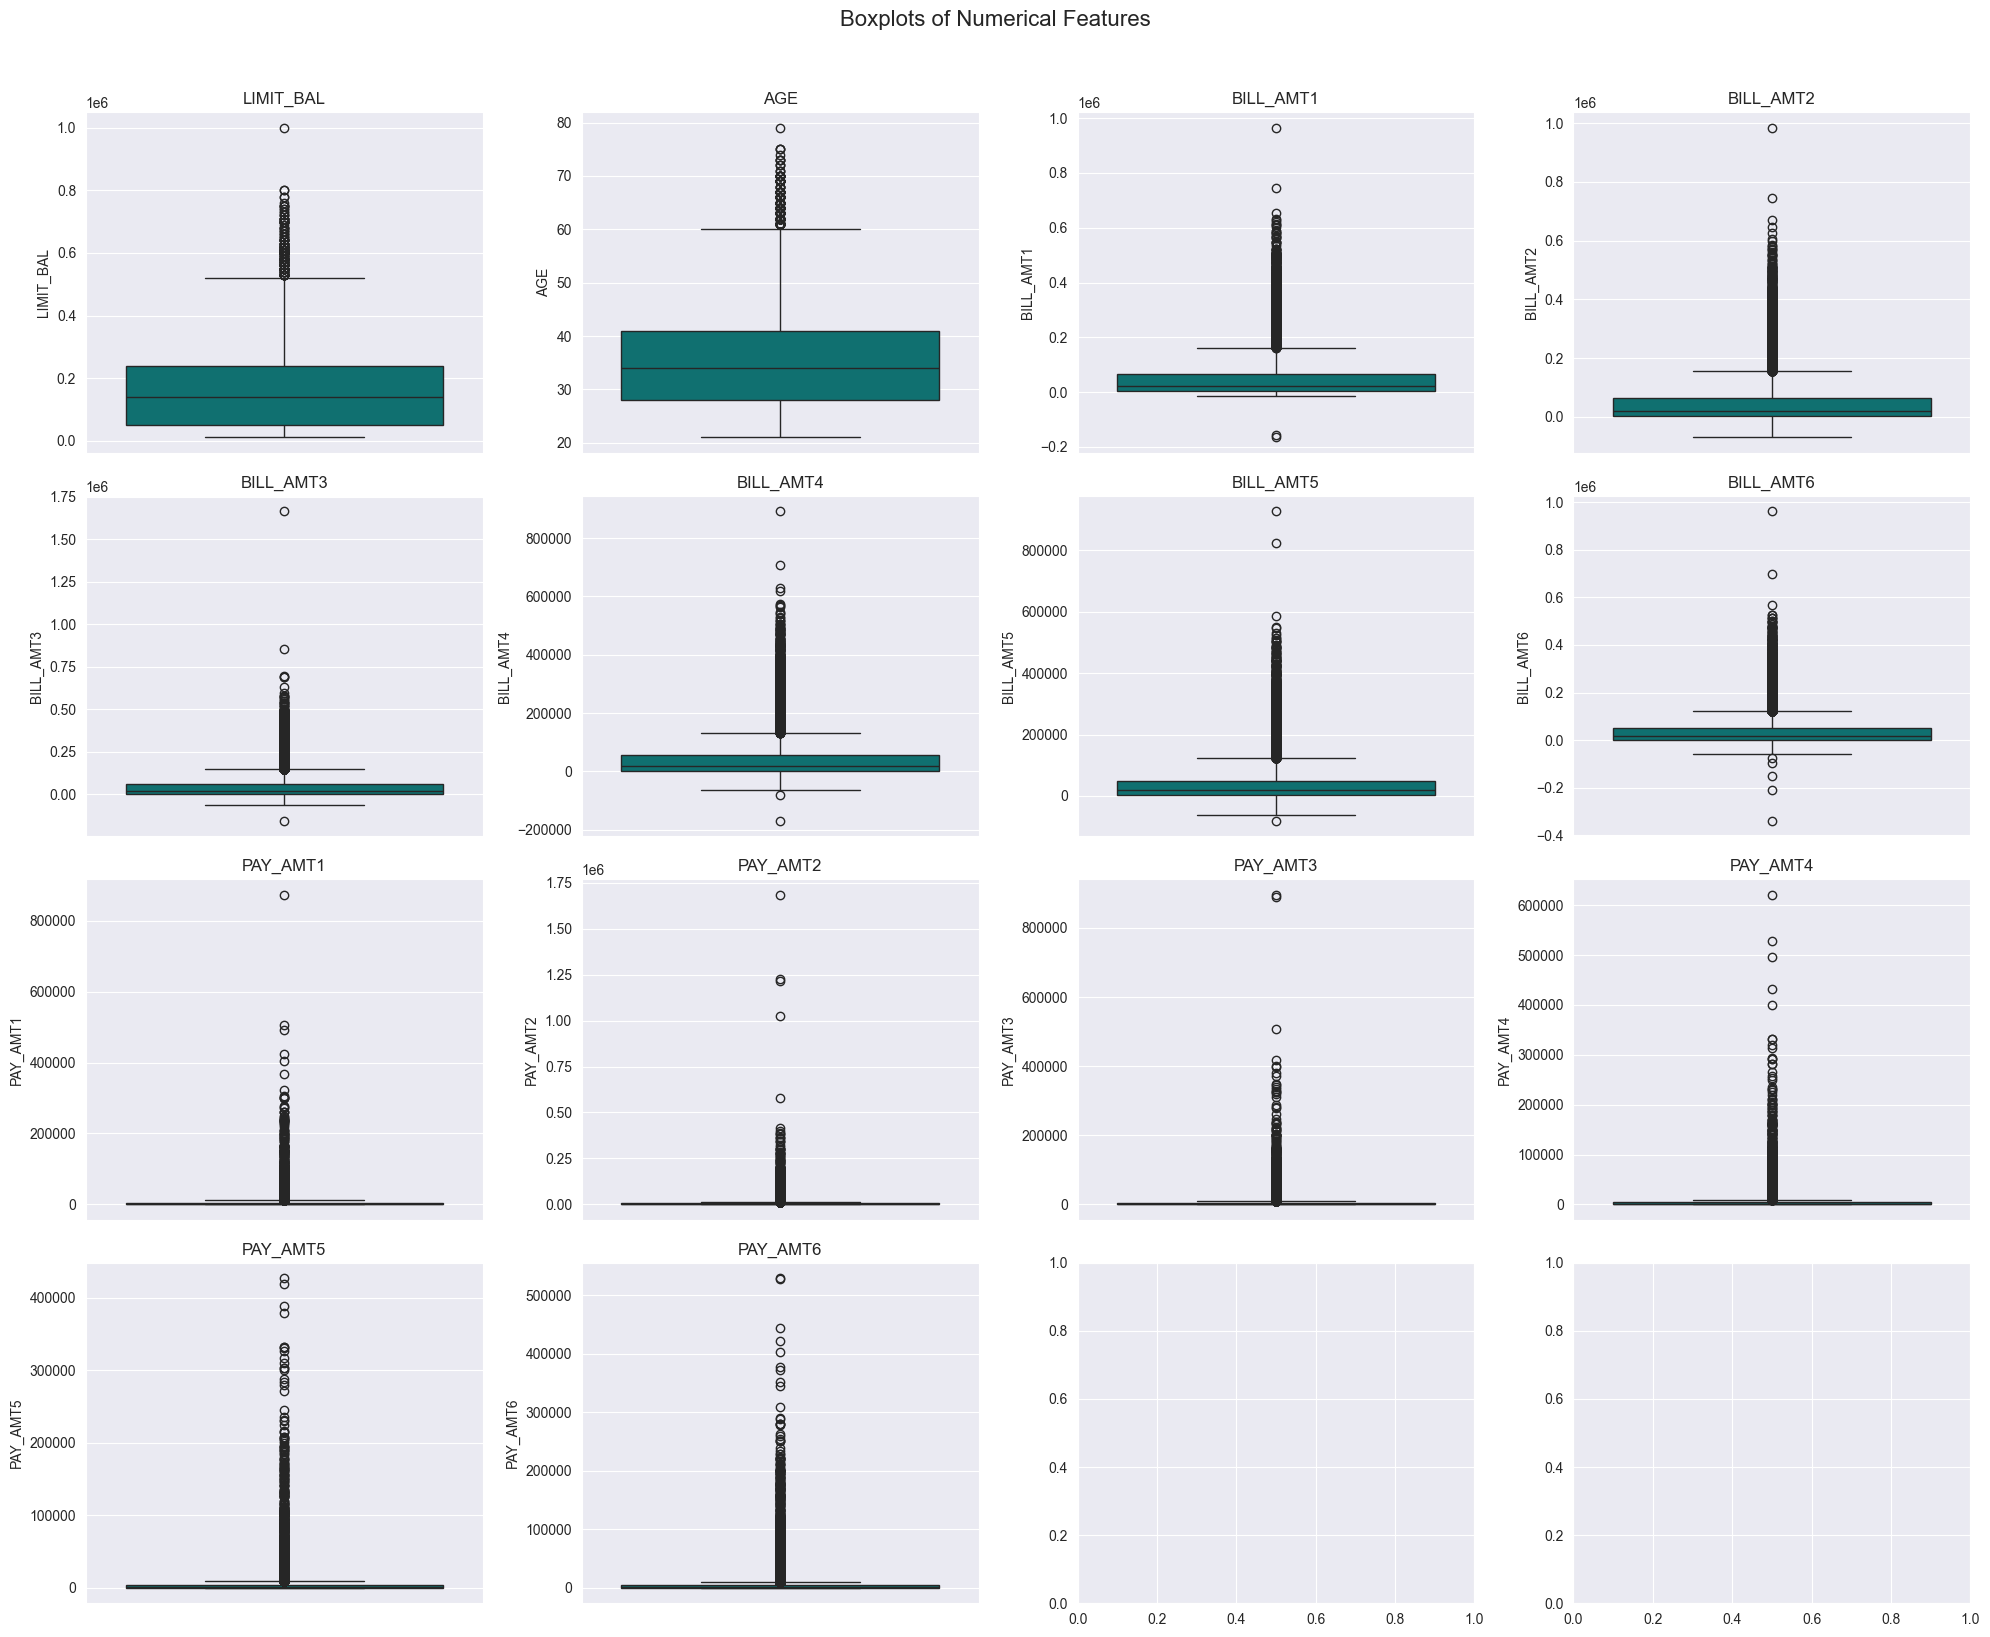

In [18]:
# Boxplots to check outliers
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

for i, j in enumerate(num_cols):
    sns.boxplot(y=df[j], ax=axes[i], color='teal')
    axes[i].set_title(j)
    axes[i].set_xlabel('')

# Hide any unused subplots
for idx in range(len(num_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Boxplots of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

* Outliers are present in every single feature — but this is expected in financial data and are real values.
* Yeo-Johnson transformation seems to be a good choice as it addresses both skewness and compresses outliers simultaneously

### Bivariate Analysis

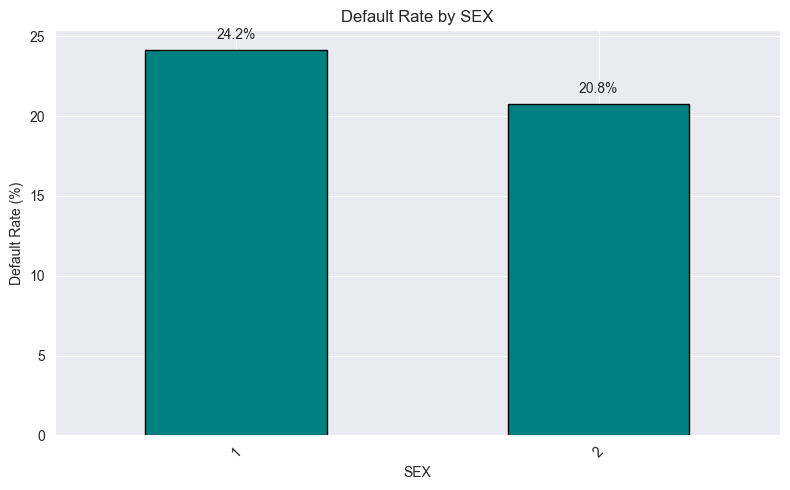

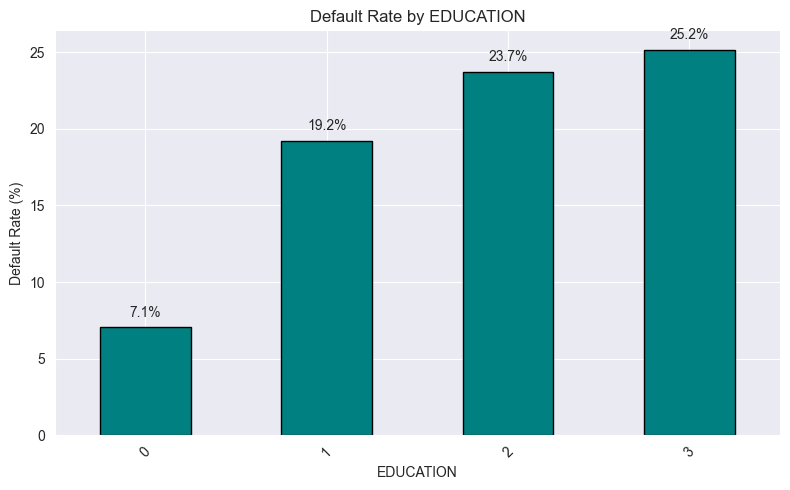

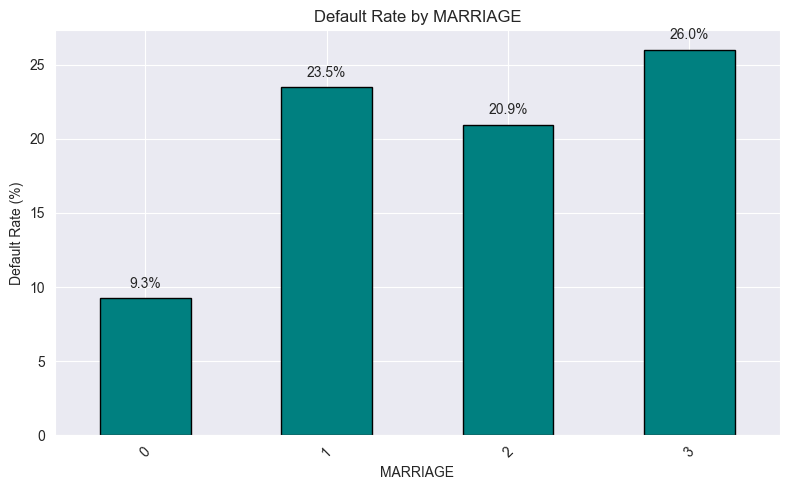

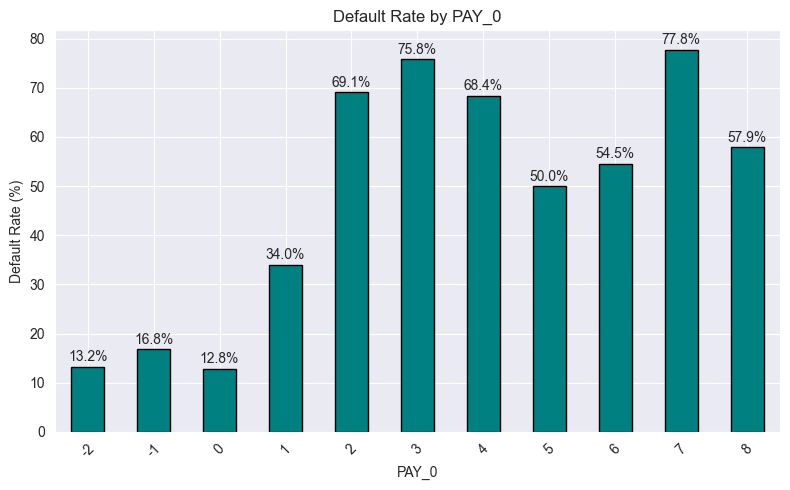

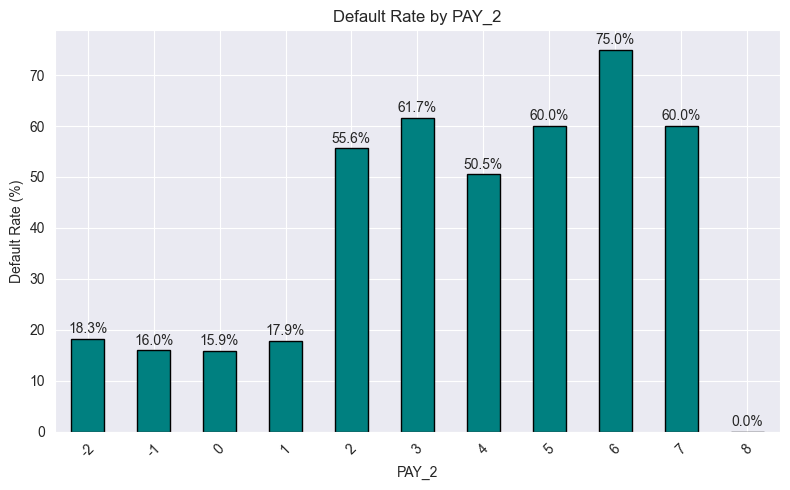

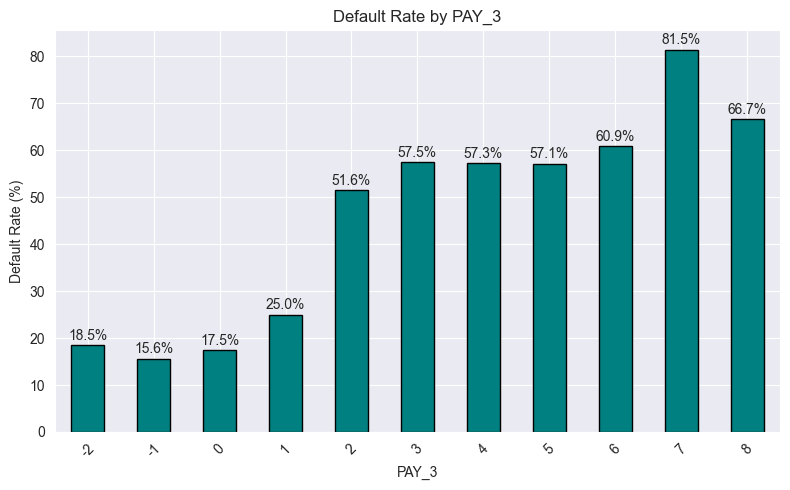

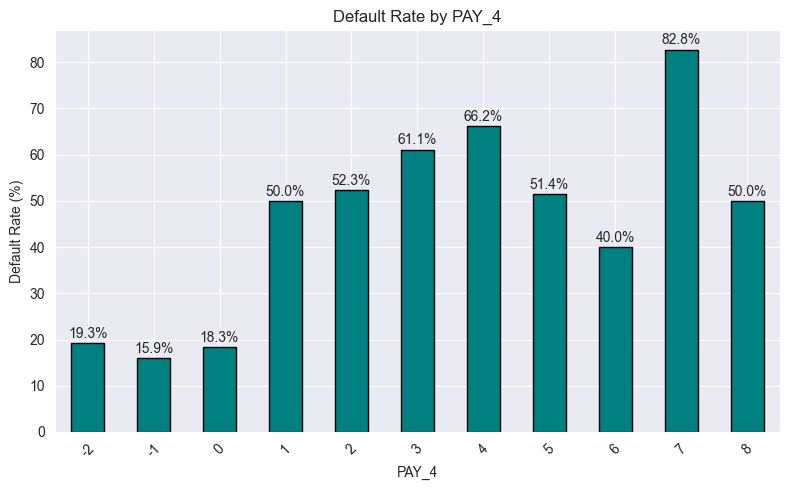

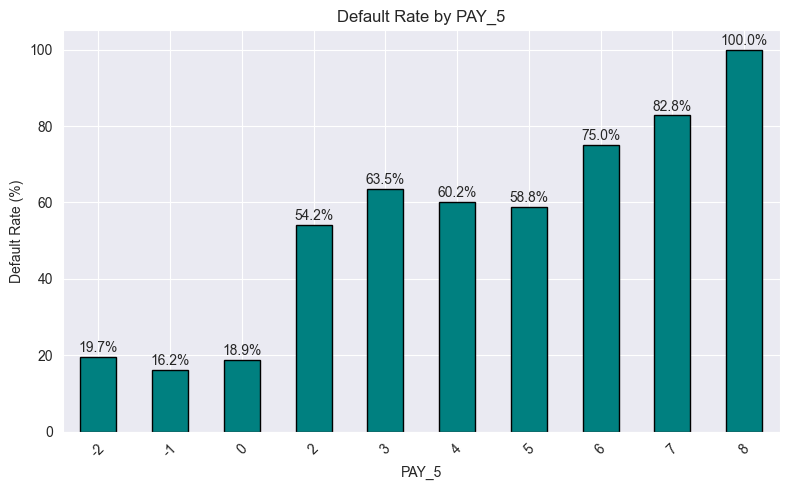

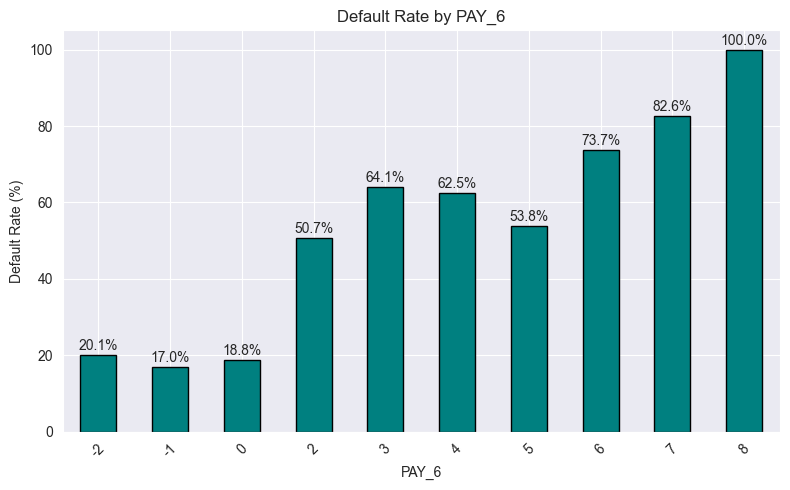

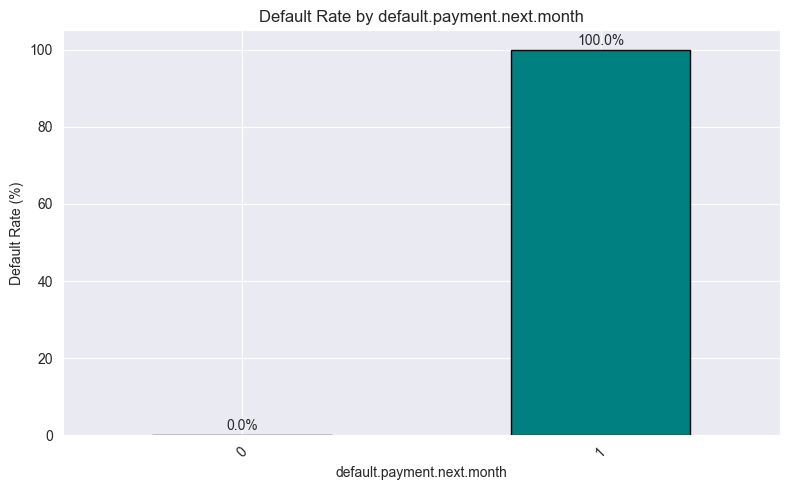

In [19]:
for col in cat_cols_list:
    plt.figure(figsize=(8, 5))

    default_rate = (cat_cols.groupby(col)['default.payment.next.month']
                    .apply(lambda x: x.astype(int).mean()) * 100)

    ax = default_rate.plot(kind='bar', color='teal', edgecolor='black')

    # Add percentage labels on top of each bar
    for i, v in enumerate(default_rate):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

    plt.title(f'Default Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

MARRIAGE and SEX seem to have low predictive power.

#### Education
* Bivariate analysis reveals a clear trend between education level and default rate — customers with lower education levels tend to default more frequently. High school graduates have the highest default rate (25.2%), followed by university graduates (23.7%) and graduate school graduates (19.2%). The unknown/others category (0) shows a notably low default rate of 7.1%, however this should be interpreted with caution as it represents only 1.6% of the dataset (~468 rows), making this estimate less statistically reliable.

#### PAY_0 - PAY_6
The PAY columns show the strongest and most consistent relationship with the target variable of any feature
in the dataset. There is a dramatic jump in default rate between the "no delay" categories and the delay categories:

- **-2, -1, 0** (no consumption, paid in full, revolving credit): default rates range from **12–20%**
- **1** (1 month delay): default rates jump to **25–50%**
- **2+** (2+ months delay): default rates rise sharply to **50–80%+**

**PAY_0** (September 2005, the most recent month) shows the sharpest and most pronounced jump, suggesting
that more recent payment behaviour is more predictive of default than older payment history.

Notable caveats:
- The 100% default rates observed for value 8 in PAY_5 and PAY_6 are unreliable, as these categories
  contain only 1–3 rows
- Similarly, the 0.0% default rate for value 8 in PAY_2 is based on a single row and should not be
  interpreted as meaningful

##### Binning Decision
Based on the bivariate analysis, the following binning strategy will be applied to all PAY columns:

| Original Values | New Value | Rationale |
|---|---|---|
| -2 | -2 | Kept separate — distinct behaviour, sufficient data |
| -1 | -1 | Kept separate — distinct behaviour, sufficient data |
| 0 | 0 | Kept separate — most common category, distinct behaviour |
| 1, 2 | 2 | Merged — value 1 is extremely sparse and shows inconsistent default rates across columns |
| 3, 4, 5, 6, 7, 8 | 3 | Merged — all show similarly high default rates (50–80%+) and are individually too sparse to be reliable |

This binning strategy is justified on two grounds: statistical sparsity of the higher delay categories,
and the similar default rates observed across values 3–8 in the bivariate analysis.


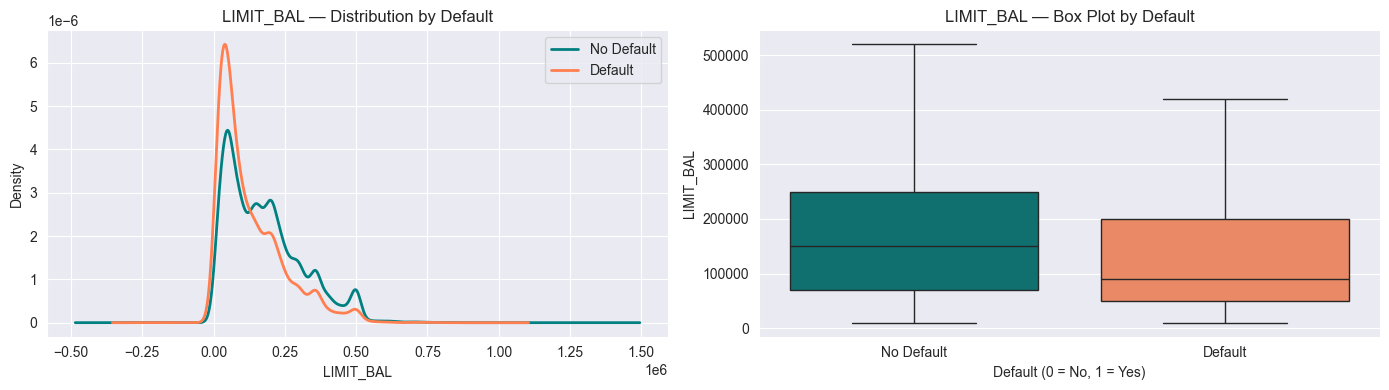

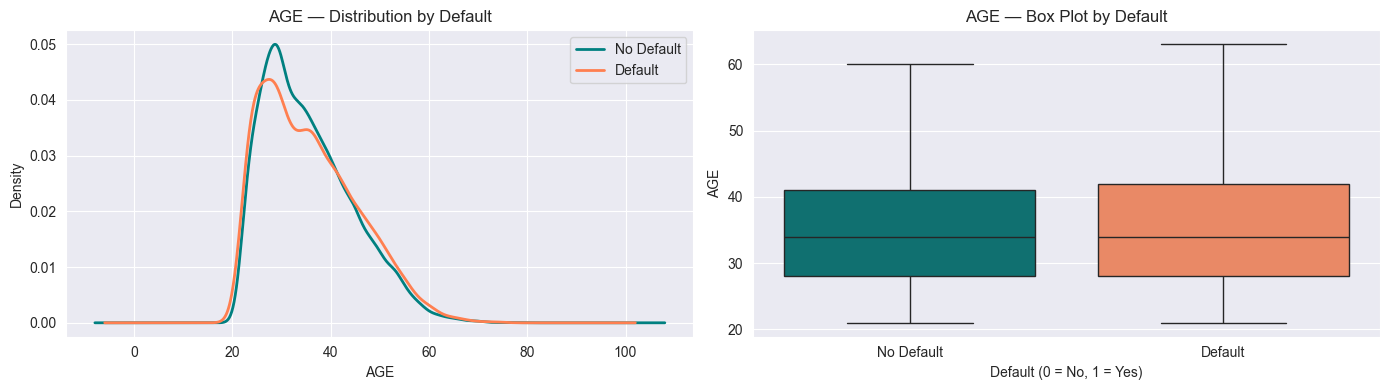

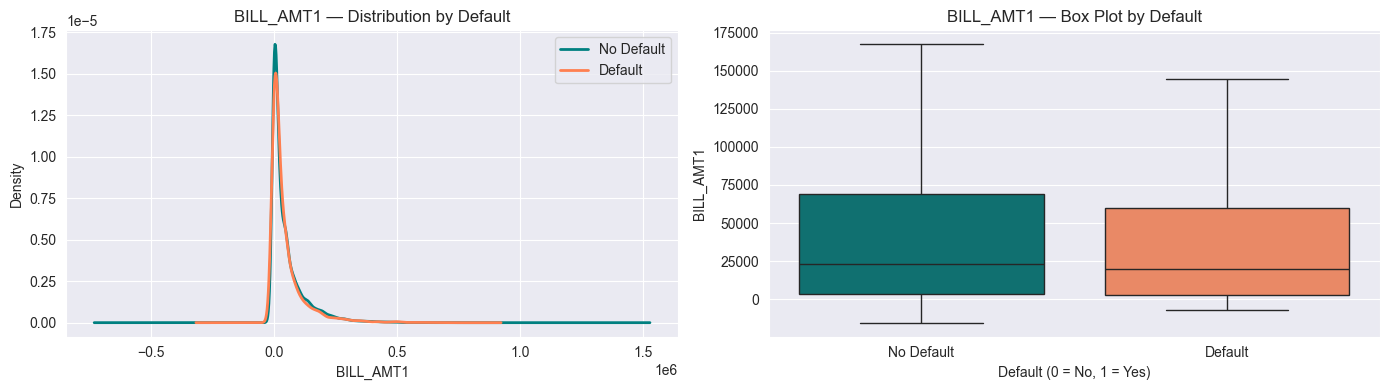

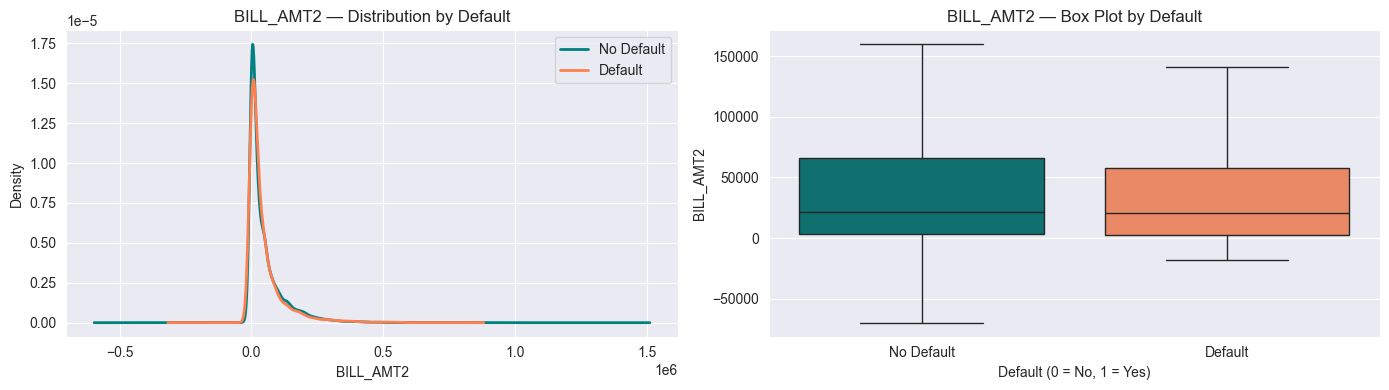

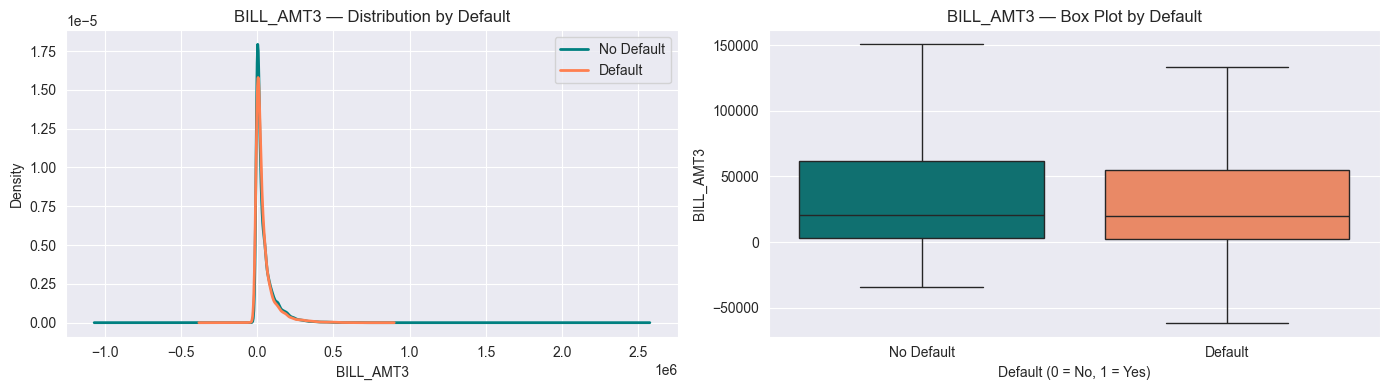

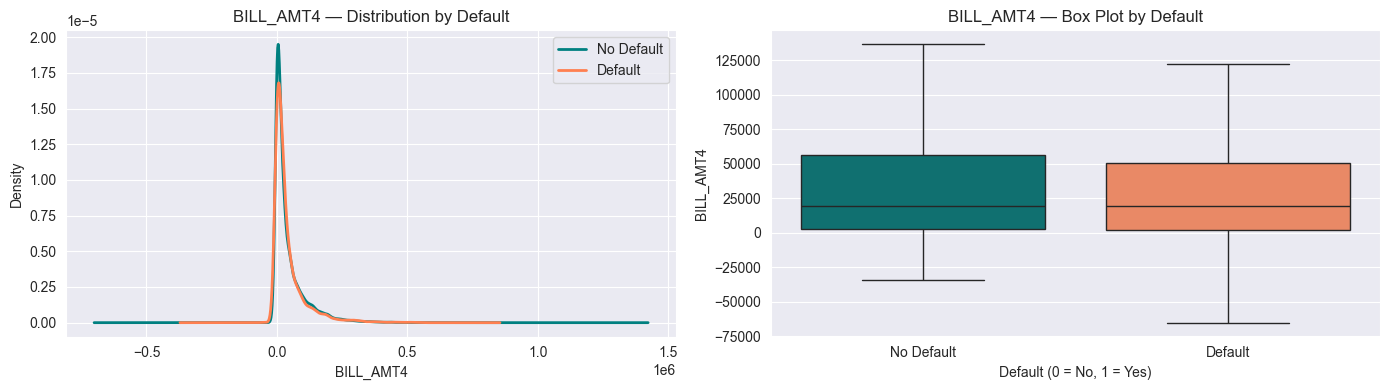

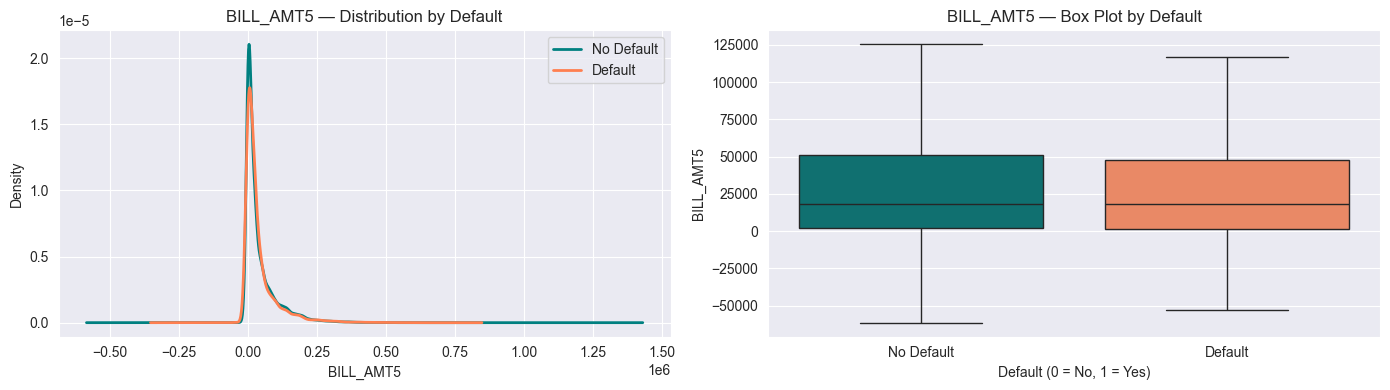

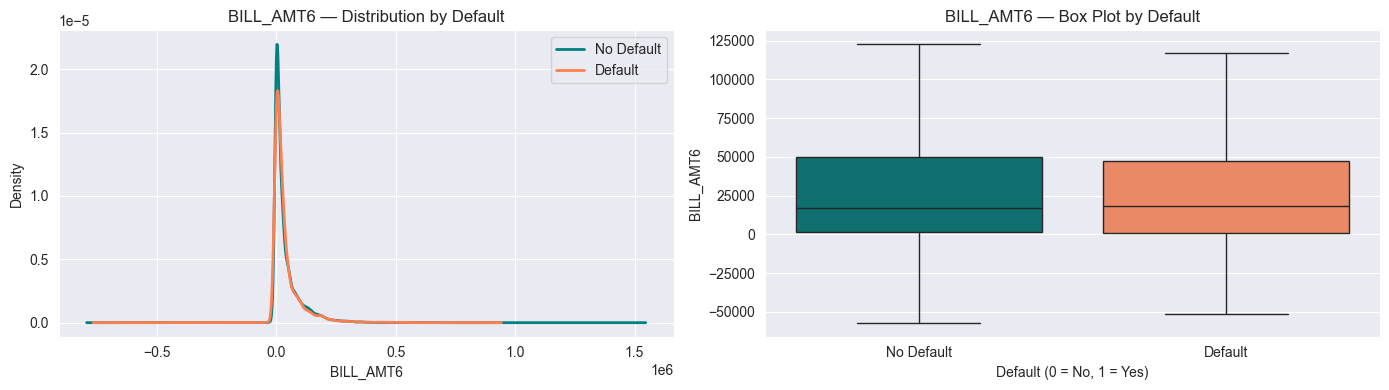

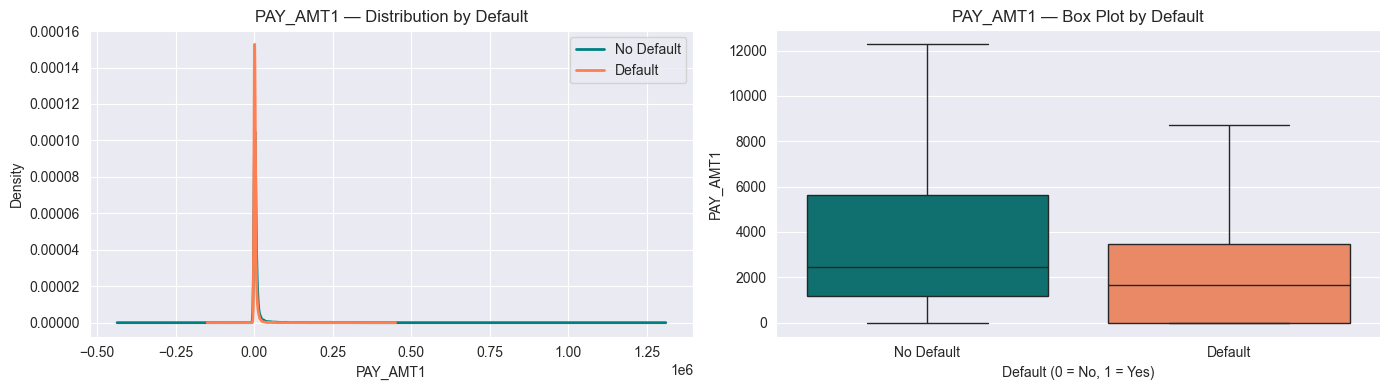

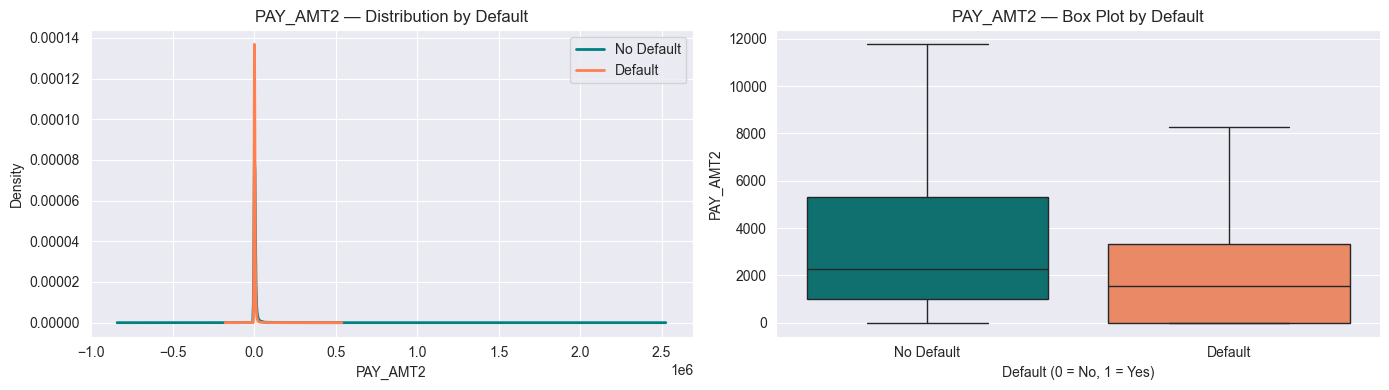

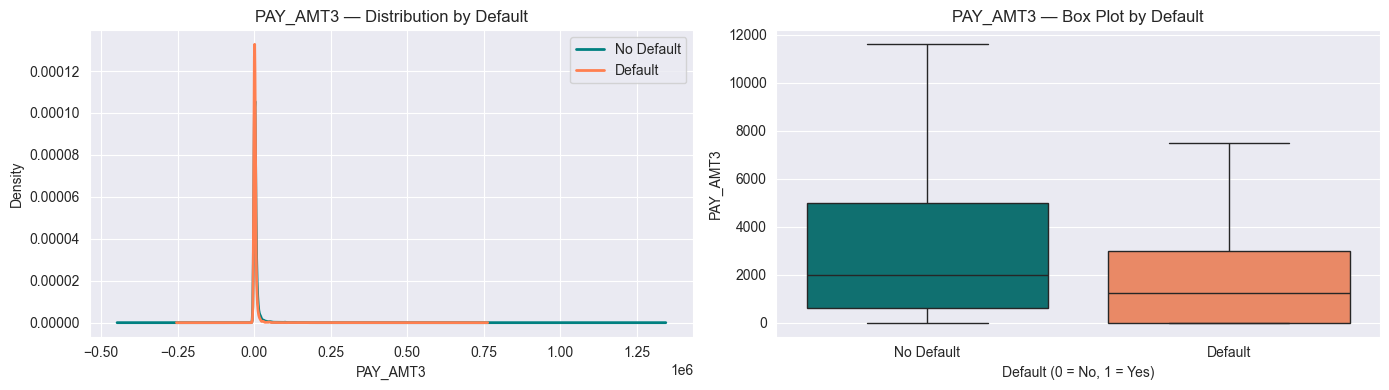

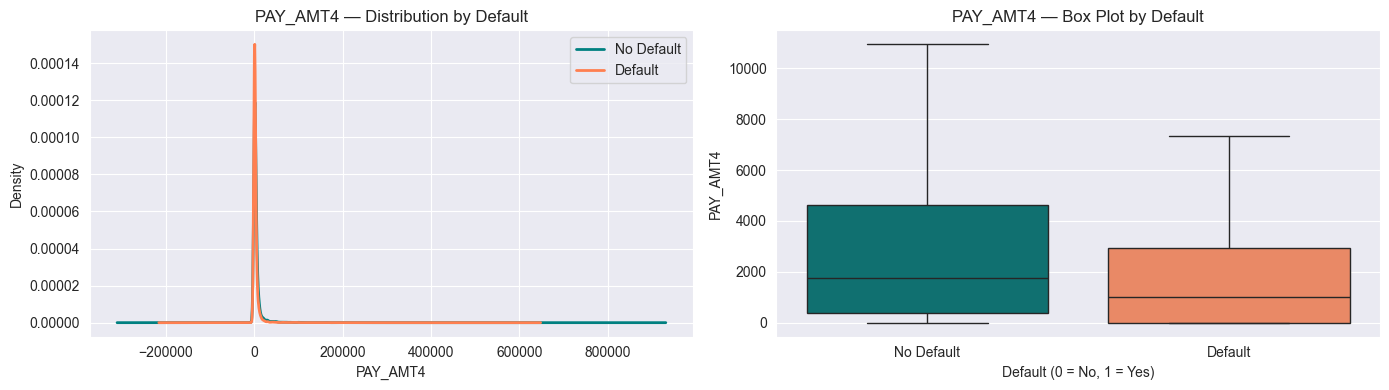

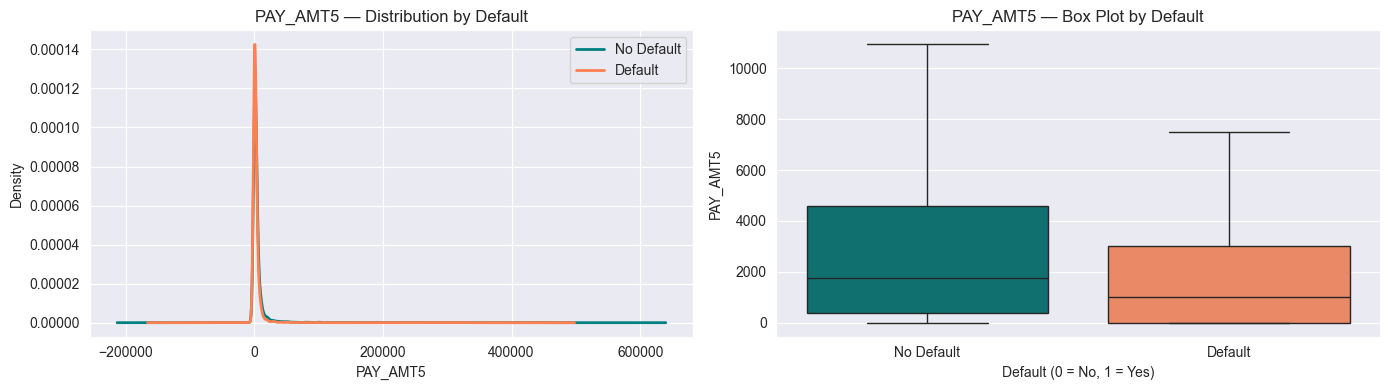

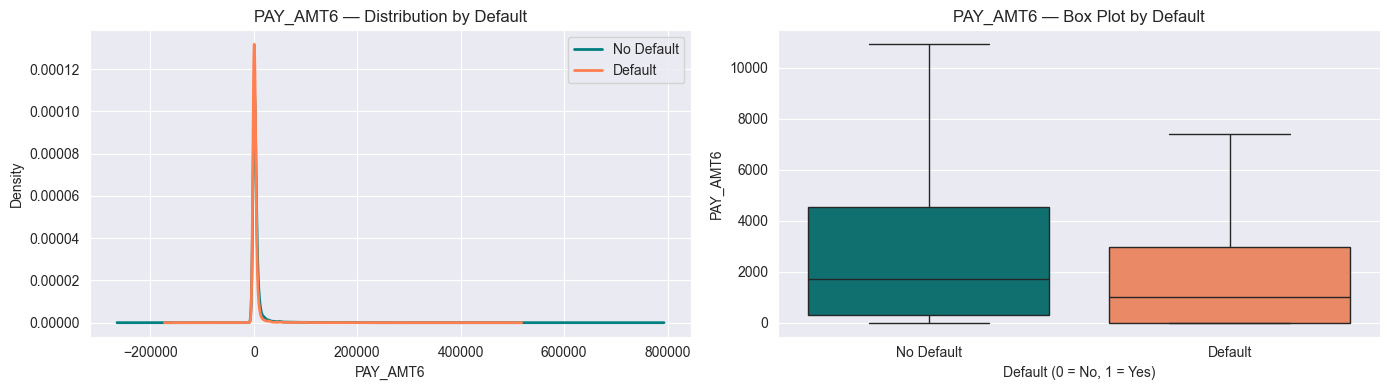

In [27]:
for col in num_cols_list:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # KDE plot — shows distribution shape and overlap
    for label, colour in zip([0, 1], ['teal', 'coral']):
        subset = df[df['default.payment.next.month'] == label][col]
        subset.plot.kde(ax=axes[0], label=f'{"No Default" if label == 0 else "Default"}',
                        color=colour, linewidth=2)
    axes[0].set_title(f'{col} — Distribution by Default')
    axes[0].set_xlabel(col)
    axes[0].legend()

    # Box plot — shows median and spread clearly
    sns.boxplot(x='default.payment.next.month', y=col, data=df,
                palette={'0': 'teal', '1': 'coral'},
                ax=axes[1], showfliers=False)  # showfliers=False hides extreme outliers
    axes[1].set_title(f'{col} — Box Plot by Default')
    axes[1].set_xlabel('Default (0 = No, 1 = Yes)')
    axes[1].set_xticklabels(['No Default', 'Default'])

    plt.tight_layout()
    plt.show()

#### AGE
- The distributions of defaulters and non-defaulters are almost identical, with both groups peaking around age 27–28 and sharing similar medians (~34–35 years).
- **AGE is a weak predictor of default on its own.** It may still contribute in combination with other features, but should not be expected to carry much weight in the model.



#### LIMIT_BAL
- Defaulters tend to have noticeably lower credit limits, with a median around 100,000 NT compared to ~150,000–160,000 NT for non-defaulters.
- The KDE shows the defaulter curve peaking sharply at low credit limits, while the non-defaulter curve is flatter and spread across higher values.
- **Lower credit limits are strongly associated with default.** This likely reflects the bank already treating these customers as higher risk at the point of credit assignment.



#### BILL_AMT1 – BILL_AMT6
- The KDE plots are uninformative due to extreme outliers stretching the x-axis. Insights are drawn from box plots only.
- Defaulters tend to have **slightly lower** bill amounts than non-defaulters, particularly in the most recent month (BILL_AMT1). This is counterintuitive but explainable — customers approaching default may have stopped using their card or reached their credit limit.
- The separation between groups fades as we move from BILL_AMT1 → BILL_AMT6, meaning **more recent bill amounts carry more signal than older ones**.
- All 6 BILL_AMT columns are likely highly correlated (bills roll over month to month), making them somewhat redundant as raw features.
- **Raw bill amounts are weak predictors.** Their predictive power will be significantly improved by engineering a utilisation ratio (BILL_AMT / LIMIT_BAL).


#### PAY_AMT1 – PAY_AMT6
- The KDE plots are again uninformative due to outliers. Insights are drawn from box plots only.
- Non-defaulters consistently make higher payments than defaulters across all 6 months. The gap is clear in every month, with non-defaulter medians roughly 1,000–1,500 NT higher.
- Unlike BILL_AMT, the separation between groups remains **stable across all 6 months**, suggesting that payment behaviour is a persistent habit rather than a recent change.
- Both groups have medians well above zero — defaulters are not simply paying nothing, they are paying proportionally less relative to what they owe.
- **PAY_AMT is a moderate predictor of default.** Its predictive power will be improved by engineering a payment ratio (PAY_AMT / BILL_AMT) and a total payments feature (sum of all 6 months).


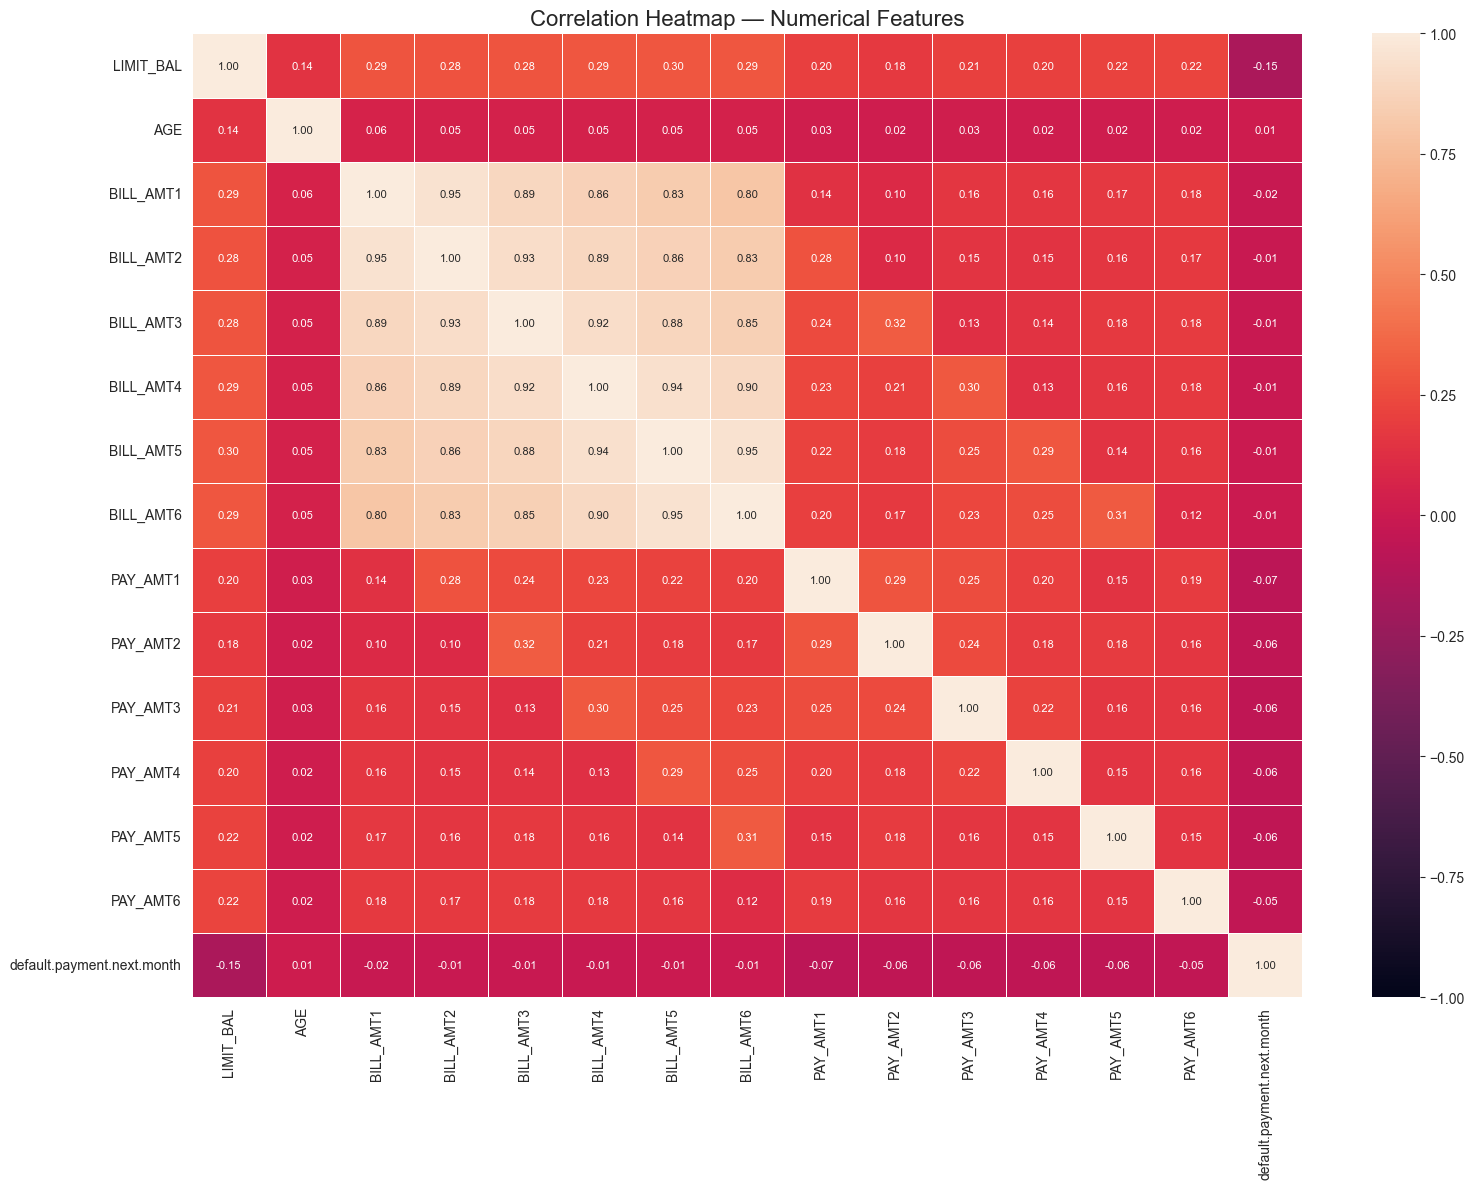

In [36]:
# Correlation Heatmap for numerical variables along with the target variable
plt.figure(figsize=(16, 12))

num_cols_with_target = df[num_cols_list + ['default.payment.next.month']]
corr_matrix = num_cols_with_target.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='rocket',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Correlation Heatmap — Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

#### BILL_AMT1 – BILL_AMT6: Extremely High Intercorrelation
* The BILL_AMT columns are very highly correlated with each other, with adjacent months correlating at 0.83–0.95.
* This is expected — outstanding bills roll over month to month, meaning each month's bill is largely just the previous month's bill carried forward.
* Feeding all 6 raw columns into the model is redundant and may hurt models sensitive to multicollinearity (e.g. Logistic Regression).
* **Action:** Replace with engineered summary features (e.g. `mean_bill_amt`, `bill_to_limit_ratio`) rather than using all 6 raw columns.

#### PAY_AMT1 – PAY_AMT6: Mild Intercorrelation
* The PAY_AMT columns correlate with each other in the 0.15–0.32 range — much lower than BILL_AMT, meaning they carry more independent information month to month.
* There is still some redundancy worth addressing.
* **Action:** Can consider aggregating into a `total_paid_6months` feature to capture the consistent payment behaviour signal across all months.

#### Correlations with Target Variable
* All numerical features show very weak linear correlation with `default.payment.next.month`, with `LIMIT_BAL` being the strongest at -0.15.
* This suggests no single raw numerical feature is a strong linear predictor of default on its own.
* This is a strong indicator that tree-based models (XGBoost, Random Forest) will outperform Logistic Regression, as they can capture non-linear relationships and feature interactions.
* It also reinforces the importance of feature engineering — ratios and aggregates are expected to be significantly more predictive than raw features.

#### AGE: Weakest Feature
* AGE shows near-zero correlation with every other feature and with the target (-0.01 to 0.14 range throughout).
* Consistent with the bivariate analysis findings — AGE is the least informative raw feature in this dataset.


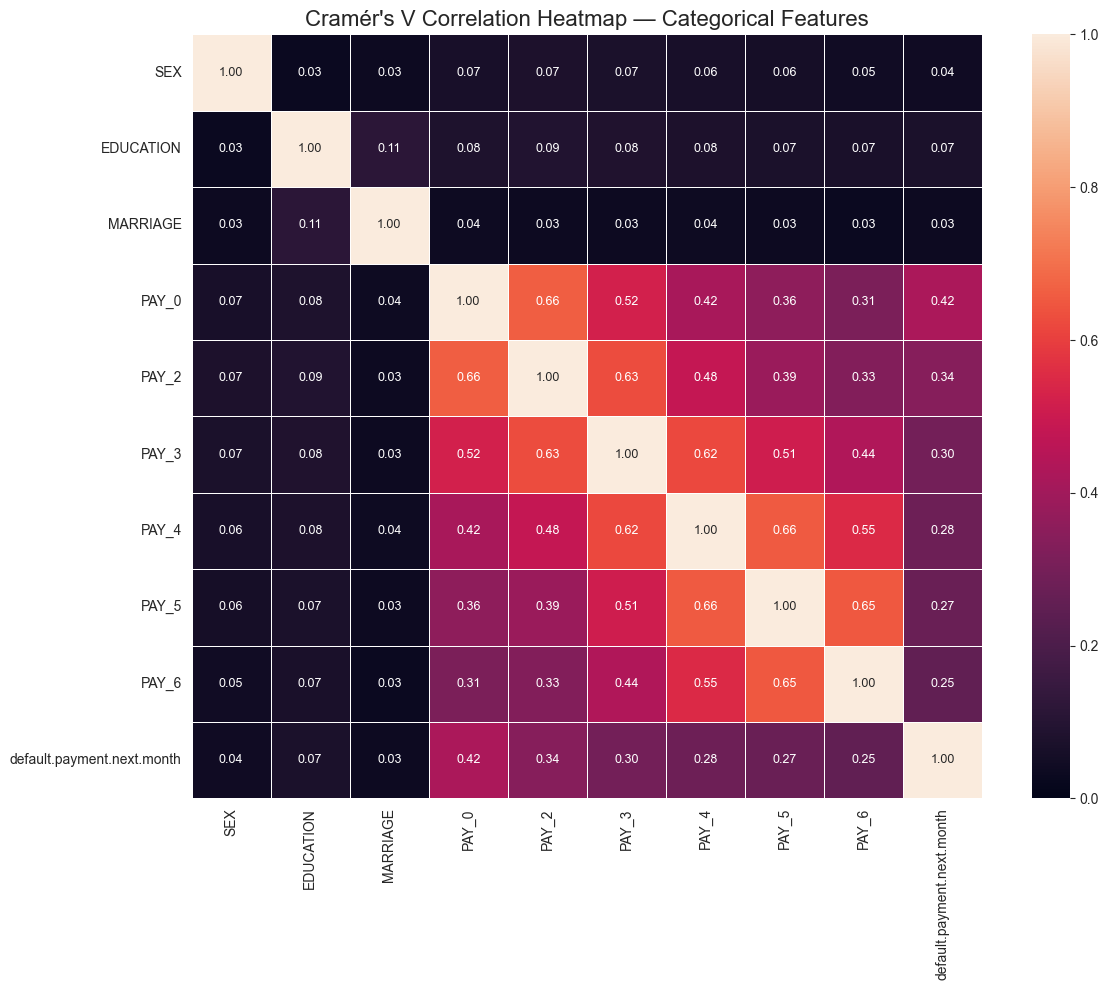

In [39]:
# Cramer's V Correlation Heatmap for categorical variables
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramers_matrix = pd.DataFrame(index=cat_cols_list, columns=cat_cols_list, dtype=float)

for col1 in cat_cols_list:
    for col2 in cat_cols_list:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

plt.figure(figsize=(12, 10))
sns.heatmap(cramers_matrix,
            annot=True,
            fmt='.2f',
            cmap='rocket',
            vmin=0, vmax=1,
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title("Cramér's V Correlation Heatmap — Categorical Features", fontsize=16)
plt.tight_layout()
plt.show()

#### SEX, EDUCATION, MARRIAGE — Negligible Predictive Power
* All three demographic features show very weak association with the target variable:
    - SEX: 0.04
    - EDUCATION: 0.07
    - MARRIAGE: 0.03
* These features also show negligible association with each other (all below 0.11), confirming they carry largely independent but weak information.
* **Action:** Retain for now and rely on model feature importance after training to decide whether to drop them.

#### PAY_0 — Strongest Categorical Predictor
* PAY_0 has the highest association with `default.payment.next.month` at 0.42, confirming that the most recent payment status is the single most predictive categorical feature in the dataset.
* Association with the target gradually decreases for older months: PAY_2 (0.34) → PAY_3 (0.30) → PAY_4 (0.28) → PAY_5 (0.27) → PAY_6 (0.25).
* **This is consistent with the intuition that recent payment behaviour is more informative than older behaviour.**

#### PAY Columns — Moderate Intercorrelation, No Redundancy Concern
* Adjacent PAY columns are moderately associated with each other (0.51–0.66 range), which is expected since payment behaviour tends to be consistent month to month.
* However, no pair exceeds the 0.85 redundancy threshold and each PAY column shows a meaningfully different association with the target.
* **Action:** Retain all PAY columns — they each contribute independent predictive signal.

#### No Columns Dropped
* No categorical feature pairs exceed the 0.70–0.85 redundancy threshold.
* **Action:** All categorical features are retained for feature engineering.